In [6]:
import pandas as pd
from pathlib import Path

In [49]:
subset_path =  "/Users/b.madran/master/protein-prediction-project/data/subset_protein_mapped_new.csv"
subset_path ="/Users/b.madran/master/protein-prediction-project/data/subset_protein_mapped_enhanced.csv"
subset = pd.read_csv(subset_path)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/b.madran/master/protein-prediction-project/data/subset_protein_mapped_enhanced.csv'

In [23]:
subset.head(5)

,domain_id,class,architecture,topology,homology,protein_sequence,domain_start,domain_end,cath,protein_length,protein_id
0,1oksA00,1,10,8,10,MASRSVIRSIIKSSRLEEDRKRYLMTLLDDIKGANDLAKFHQMLVK...,2,55,1.10.8.10,56,1oks
1,4dbgB02,1,10,8,10,GPLGSRQDKMREEGLQLVSMIREGEAAGACPEEIFSALQYSGTEVP...,55,115,1.10.8.10,162,4dbg
2,4un2B00,1,10,8,10,GSPEERYEHQLRQLNDMGFFDFDRNVAALRRSGGSVQGALDSLLNGDV,2,44,1.10.8.10,48,4un2
3,1oaiA00,1,10,8,10,PTLSPEQQEMLQAFSTQSGMNLEWSQKCLQDNNWDYTRSAQAFTHL...,1,59,1.10.8.10,59,1oai
4,1g3iW02,1,10,8,10,MSEMTPREIVSELDQHIIGQADAKRAVAIALRNRWRRMQLQEPLRH...,110,244,1.10.8.10,444,1g3i


In [24]:
prot_folder = Path("/Users/b.madran/master/protein-prediction-project/data/prot_embeddings")
domain_ids = [f.stem for f in prot_folder.glob('*.npy')]
domain_ids

['8sfuA02',
 '8t2vA02',
 '8swjA01',
 '8kczA01',
 '8tfgA01',
 '8ofbA03',
 '8inpA01',
 '8tfgA02',
 '8spoE01',
 '8hpoK01',
 '8pkpK01',
 '8tmsA01',
 '8owaA01',
 '8onjA02',
 '8ornD01',
 '8ormI01',
 '8p97A01',
 '8iprA01',
 '8iuhP01',
 '8onjA01',
 '8qelA02',
 '8iprC01',
 '8ormI02',
 '8hp8A01',
 '8onoA01',
 '8izeA01',
 '8owfA01',
 '8p5sA01',
 '8p4bI01',
 '8jitR01',
 '8t5tA01',
 '8jfdA01',
 '8sppA01',
 '8s93A01',
 '8oizB01',
 '8jpdG01',
 '8w6xS01',
 '8i3jA01',
 '8sdbA03',
 '8slfB01',
 '8oizB02',
 '8tk7A01',
 '8iw1R01',
 '8iahY01',
 '8ojhB03',
 '8q1nB01',
 '8pu6A01',
 '8oxuA01',
 '8w6xL01',
 '8oxuA02']

In [25]:
subset50 = subset[subset['domain_id'].isin(domain_ids)]
subset50 = subset50.reset_index(drop=True)

In [33]:
subset50.head(3)

,domain_id,class,architecture,topology,homology,protein_sequence,domain_start,domain_end,cath,protein_length,protein_id
0,8iuhP01,1,10,10,10,MAEVKVKVQPPDADPVEIENRIIELCHQFPHGITDQVIQNEMPHIE...,15,76,1.10.10.10,316,8iuh
1,8qelA02,1,10,150,190,SHCRFYENKYPEIDDIVMVNVQQIAEMGAYVKLLEYDNIEGMILLS...,90,170,1.10.150.190,173,8qel
2,8jpdG01,1,10,167,10,ADLEAVLADVSYLMAMEKSKATPAARASKKILLPEPSIRSVMQKYL...,38,182,1.10.167.10,688,8jpd


In [27]:
subset50.to_csv("/Users/b.madran/master/protein-prediction-project/data/subset50.cvs", index=False)


Prediction

Generated visualization for protein 1
Generated visualization for protein 2
Generated visualization for protein 3
Generated visualization for protein 4
Generated visualization for protein 5
Generated visualization for protein 6
Generated visualization for protein 7
Generated visualization for protein 8
Generated visualization for protein 9
Generated visualization for protein 10
Generated visualization for protein 11
Generated visualization for protein 12
Generated visualization for protein 13
Generated visualization for protein 14
Generated visualization for protein 15
Generated visualization for protein 16
Generated visualization for protein 17
Generated visualization for protein 18
Generated visualization for protein 19
Generated visualization for protein 20
Generated visualization for protein 21
Generated visualization for protein 22
Generated visualization for protein 23
Generated visualization for protein 24
Generated visualization for protein 25
Generated visualization for protei

KeyboardInterrupt: 

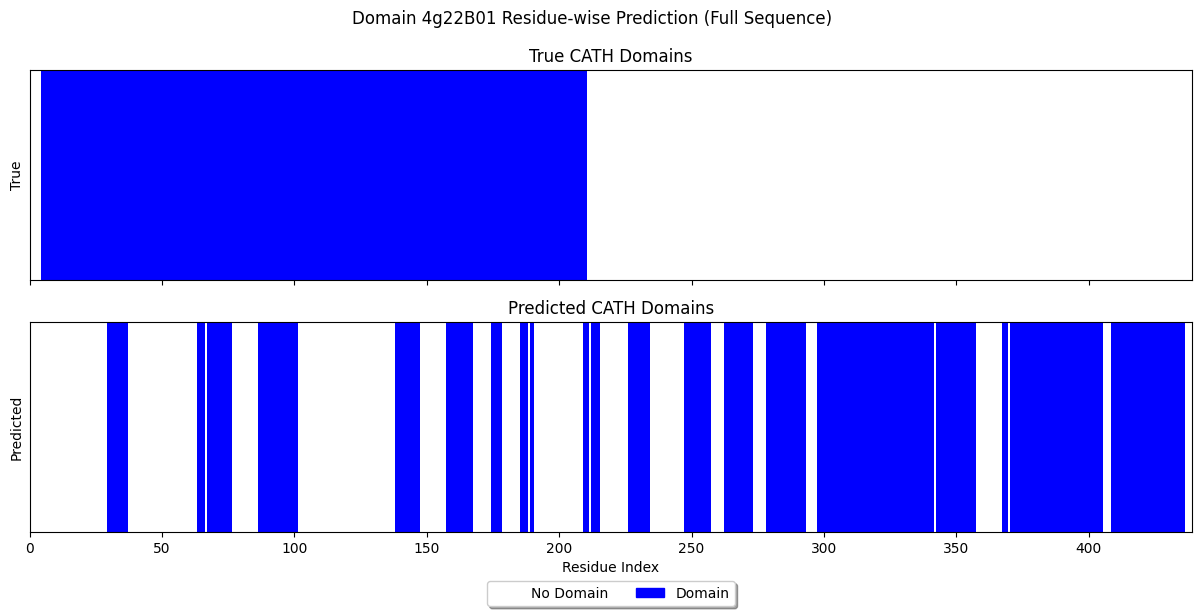

In [55]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap

LABELS = {
    'NO_DOMAIN_REGION': 0,
    'DOMAIN_START': 1,
    'DOMAIN_MIDDLE': 2,
    'DOMAIN_END': 3,
}

# Setup: blue for any domain, white for no domain
cmap_colors = ['white', 'blue', 'blue', 'blue']  # Indexed by label value
custom_cmap = ListedColormap(cmap_colors)
vmin_plot = 0
vmax_plot = 3  # max label

# Load predictions
with open("/Users/bene/Developer/protein-prediction-project/data/domain_boundary_predictions.json", 'r') as f:
    data = [json.loads(line) for line in f]

# Load ground truth
subset50 = pd.read_csv("/Users/bene/Developer/protein-prediction-project/data/subset_protein_mapped_enhanced_limited_len_600.csv")
subset50 = subset50.set_index("domain_id")

output_dir = "output_plots"
os.makedirs(output_dir, exist_ok=True)

visualized_count = 0

for entry in data:
    domain_id = entry['domain_id']
    pred_arr = np.array(entry['prediction'])

    if domain_id not in subset50.index:
        print(f"Skipping domain {domain_id} — not found in subset50.")
        continue

    row = subset50.loc[domain_id]
    protein_length = int(row['protein_length'])
    domain_start = int(row['domain_start']) - 1  # switch to 0-based
    domain_end = int(row['domain_end'])         # already inclusive

    # Ground truth label vector
    true_labels = np.full(protein_length, LABELS['NO_DOMAIN_REGION'])
    if domain_end > domain_start:
        true_labels[domain_start] = LABELS['DOMAIN_START']
        true_labels[domain_start + 1:domain_end - 1] = LABELS['DOMAIN_MIDDLE']
        true_labels[domain_end - 1] = LABELS['DOMAIN_END']

    # Resize prediction to match protein_length (if needed)
    if len(pred_arr) < protein_length:
        padded_pred = np.full(protein_length, LABELS['NO_DOMAIN_REGION'])
        padded_pred[:len(pred_arr)] = pred_arr
        pred_arr = padded_pred
    elif len(pred_arr) > protein_length:
        pred_arr = pred_arr[:protein_length]

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
    fig.suptitle(f"Domain {domain_id} Residue-wise Prediction (Full Sequence)")

    ax1.imshow(true_labels.reshape(1, -1), cmap=custom_cmap, aspect='auto',
               extent=[0, protein_length, 0, 1], vmin=vmin_plot, vmax=vmax_plot)
    ax1.set_yticks([])
    ax1.set_title("True CATH Domains")
    ax1.set_ylabel("True")
    ax1.set_xlim(0, protein_length)

    ax2.imshow(pred_arr.reshape(1, -1), cmap=custom_cmap, aspect='auto',
               extent=[0, protein_length, 0, 1], vmin=vmin_plot, vmax=vmax_plot)
    ax2.set_yticks([])
    ax2.set_title("Predicted CATH Domains")
    ax2.set_xlabel("Residue Index")
    ax2.set_ylabel("Predicted")
    ax2.set_xlim(0, protein_length)

    # Add legend
    handles = [plt.Rectangle((0, 0), 1, 1, color=color)
               for color in ['white', 'blue']]
    ax2.legend(handles, ['No Domain', 'Domain'], loc='upper center', bbox_to_anchor=(0.5, -0.2),
               fancybox=True, shadow=True, ncol=2)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(output_dir, f"{domain_id}.png"))
    plt.close(fig)

    visualized_count += 1
    print(f"Generated visualization for protein {visualized_count}")
